<a href="https://colab.research.google.com/github/PacktPublishing/Modern-Computer-Vision-with-PyTorch/blob/master/Chapter03/Inspecting_grayscale_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

第三章 使用PyTorch构建深度神经网络

第一节 将图像转换成结构化数组和标量

In [7]:
!wget -q https://www.dropbox.com/s/lpw10qawsc5ipbn/MyImage.JPG -O MyImage.jpg

In [2]:
!ls -lh /content/IMG_1256.JPG
#检查下载文件的大小

-rw-r--r-- 1 root root 203K Aug 13 08:14 /content/IMG_1256.JPG


In [6]:
%matplotlib inline
import cv2, matplotlib.pyplot as plt
img = cv2.imread('/content/IMG_1256.JPG')
print( img.shape )

(720, 1280, 3)


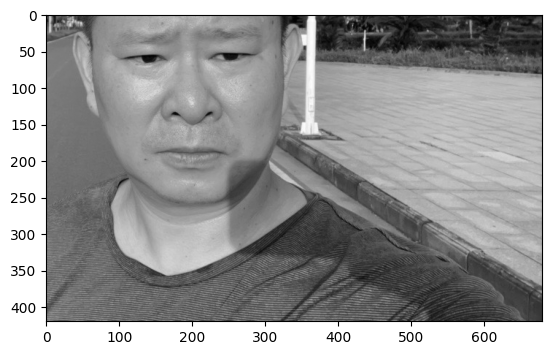

In [7]:
img = img[300:720,600:1280]
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(img_gray, cmap='gray')

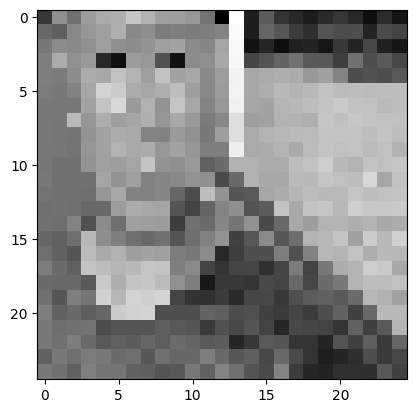

In [8]:
img_gray_small = cv2.resize(img_gray,(25,25))   #将图片转为 25*25的数组，并绘制出来
plt.imshow(img_gray_small, cmap='gray')

In [9]:
print(img_gray_small)

[[ 57 136 108 147 160 163 185 166 150 149 143 111   8 236  34  90  56  45
   33  47  57  45  21  48  26]
 [101  93 130 143 150 165 130 135 119 121 118 121 125 230  34  99  86  63
   50  83  77  78  40  75  68]
 [114 132 130 137 150 136 133 140 151 154 131 128 155 229  25  42  21  38
   40  29  59  41  72  37  28]
 [121 162 137 145  45  23 147 144  81  24 132 136 158 228  70  83  97 109
   89  87  64 109  78  88  72]
 [121 118 133 162 157 180 169 150 181 154 157 130 149 224 157 161 163 161
  144 151 126  77  81  78  89]
 [119 117 124 156 196 189 161 157 164 178 149 129 147 225 156 163 173 168
  172 181 175 177 175 177 177]
 [117 115 115 154 183 201 146 167 139 184 157 126 144 223 155 154 170 172
  178 183 188 181 180 174 177]
 [115 114 173 141 163 150 155 165 141 159 145 118 129 206 150 152 168 169
  163 184 179 185 183 181 179]
 [117 114 113 139 153 162 159 126 124 146 138 115 149 205 160 168 171 174
  175 183 183 182 178 182 177]
 [115 114 112 142 153 168 159 162 143 154 141 121 121 2

In [11]:
!pip install xlsxwriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.3/172.3 kB 12.4 MB/s eta 0:00:00


In [12]:
#写入到excel中形成热力图风格
import numpy as np
import pandas as pd

# 假设你的数组叫 data
data = np.array([
    [57,136,108,147,160,163,185,166,150,149,143,111,8,236,34,90,56,45,33,47,57,45,21,48,26],
    [101,93,130,143,150,165,130,135,119,121,118,121,125,230,34,99,86,63,50,83,77,78,40,75,68],
    [114,132,130,137,150,136,133,140,151,154,131,128,155,229,25,42,21,38,40,29,59,41,72,37,28],
    [121,162,137,145,45,23,147,144,81,24,132,136,158,228,70,83,97,109,89,87,64,109,78,88,72],
    [121,118,133,162,157,180,169,150,181,154,157,130,149,224,157,161,163,161,144,151,126,77,81,78,89],
    [119,117,124,156,196,189,161,157,164,178,149,129,147,225,156,163,173,168,172,181,175,177,175,177,177],
    [117,115,115,154,183,201,146,167,139,184,157,126,144,223,155,154,170,172,178,183,188,181,180,174,177],
    [115,114,173,141,163,150,155,165,141,159,145,118,129,206,150,152,168,169,163,184,179,185,183,181,179],
    [117,114,113,139,153,162,159,126,124,146,138,115,149,205,160,168,171,174,175,183,183,182,178,182,177],
    [115,114,112,142,153,168,159,162,143,154,141,121,121,220,160,162,169,160,176,182,179,183,175,179,167],
    [114,110,110,139,152,148,155,182,140,136,145,94,105,167,166,161,161,177,181,191,173,168,183,179,185],
    [117,110,109,108,155,139,151,123,128,130,140,136,75,103,167,158,157,174,173,184,179,177,200,156,180],
    [111,109,108,106,142,158,124,123,128,100,77,177,139,84,89,156,161,170,177,173,174,184,178,180,183],
    [107,109,107,102,103,148,162,157,155,84,68,98,126,135,82,90,182,159,181,185,172,192,186,186,188],
    [108,106,126,80,132,107,151,149,147,62,109,104,128,113,138,74,103,159,148,169,169,163,168,158,162],
    [100,94,107,172,135,121,108,103,110,85,106,123,139,65,86,131,86,106,168,171,183,151,190,172,194],
    [107,95,85,175,159,166,149,154,151,119,116,132,45,64,79,79,121,79,124,171,169,182,163,173,171],
    [120,105,95,182,177,170,172,184,182,121,131,68,56,70,71,51,70,119,68,117,162,169,192,188,158],
    [104,102,101,88,188,163,183,185,175,137,121,29,59,59,56,74,69,101,72,105,116,169,177,176,179],
    [108,85,121,113,194,171,196,193,196,70,54,52,61,46,71,72,59,78,90,95,89,104,171,166,152],
    [121,95,101,92,100,190,195,197,79,78,79,97,93,77,80,66,61,69,62,78,96,67,102,172,172],
    [117,106,110,111,77,83,84,84,93,89,85,60,81,73,85,68,43,73,70,68,56,95,65,89,170],
    [117,109,120,104,89,94,90,99,91,105,98,89,90,42,57,88,84,55,55,41,83,66,93,60,100],
    [95,117,107,119,116,105,107,86,108,100,101,121,103,86,93,73,102,75,56,35,41,49,78,61,72],
    [116,110,94,122,113,112,96,93,84,87,115,95,126,107,84,75,125,63,42,39,51,52,50,87,66]
])

# 2️⃣ 转为DataFrame
df = pd.DataFrame(data)

# 3️⃣ 保存到 Excel 并做条件格式（颜色编码）
excel_file = "/content/colored_array.xlsx"

with pd.ExcelWriter(excel_file, engine='xlsxwriter') as writer:
    df.to_excel(writer, index=False, header=False)  # 不保存行列索引
    workbook = writer.book
    worksheet = writer.sheets['Sheet1']

    # 条件格式：按数值渐变颜色
    worksheet.conditional_format(0, 0, df.shape[0]-1, df.shape[1]-1,
                                 {'type': '3_color_scale',
                                  'min_color': "#63BE7B",   # 绿色
                                  'mid_color': "#FFEB84",   # 黄色
                                  'max_color': "#F8696B"})  # 红色

print(f"Excel文件已保存到 {excel_file}")


Excel文件已保存到 /content/colored_array.xlsx


第三章 第二节 Inspecting_color_images 查看图片的颜色通道